# **Conservation Areas - ACUS Zamora Chinchipe**

Author: Daning Montaño - Ocampo

Kernel: R

# **1. Packages and libraries**

In [20]:
# ----------------------------
# 1. Paquetes
# ----------------------------
libs <- c("terra", "sf", "dplyr", "readr", "purrr", "stringr", "tidyr", "ggplot2", "scales")
invisible(lapply(libs, function(x) {
  if (!requireNamespace(x, quietly = TRUE)) install.packages(x)
  library(x, character.only = TRUE)
}))
source("../functions/themes_nci_zch.R")

# **2. Load data**

In [21]:
aoi = st_read("../../../DATOS/SHP/Limites_politicos/Provincia_ZCh_5km_buffer.shp")
zamora_ch = st_read("../../../DATOS/SHP/Limites_politicos/Provincia_ZCh.shp")
acus_area = st_read("../../../DATOS/SHP/ACUS/ACUS_ZCH_fix.shp")

Reading layer `Provincia_ZCh_5km_buffer' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Limites_politicos\Provincia_ZCh_5km_buffer.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 664270.2 ymin: 9435300 xmax: 802756.4 ymax: 9640425
Projected CRS: WGS 84 / UTM zone 17S
Reading layer `Provincia_ZCh' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Limites_politicos\Provincia_ZCh.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 674165.2 ymin: 9445216 xmax: 792756.4 ymax: 9630431
Projected CRS: WGS 84 / UTM zone 17S
Reading layer `ACUS_ZCH_fix' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\ACUS\ACUS_ZCH_fix.shp' using driver `ESRI Shapefile'
Simple feature collection with 4 features and 2 fields
Geometry 

## 2.1 Richness

In [22]:


birds_richness      <- rast("../../../DATOS/Raster/Richness/Birds_richness_z_ch.tif")
amphibians_richness <- rast("../../../DATOS/Raster/Richness/Amphibians_richness_z_ch.tif")
plants_richness     <- rast("../../../DATOS/Raster/Richness/Plants_richness_z_ch.tif")
mammals_richness    <- rast("../../../DATOS/Raster/Richness/Mammals_richness_z_ch.tif")
reptiles_richness   <- rast("../../../DATOS/Raster/Richness/Reptiles_richness_z_ch.tif")

# Raster de referencia
r_base <- birds_richness

# Función robusta de alineación
alinear_raster <- function(r, ref, method = "bilinear") {
  
  # 1. Reproyectar solo si el CRS es diferente
  if (!same.crs(r, ref)) {
    r <- project(r, ref, method = method)
  }
  
  # 2. Extender si el raster no cubre toda la extensión del raster base
  # esto evita recortes raros y mantiene la cobertura esperada
  r <- extend(r, ref)
  
  # 3. Ajustar exactamente al grid/resolución/origen del raster base
  r <- resample(r, ref, method = method)
  
  # 4. Forzar misma extensión exacta
  r <- crop(r, ref)
  
  return(r)
}

# Alinear todos
amphibians_richness <- alinear_raster(amphibians_richness, r_base)
plants_richness     <- alinear_raster(plants_richness, r_base)
mammals_richness    <- alinear_raster(mammals_richness, r_base)
reptiles_richness   <- alinear_raster(reptiles_richness, r_base)

# Renombrar capas
names(birds_richness)      <- "birds"
names(amphibians_richness) <- "amphibians"
names(plants_richness)     <- "plants"
names(mammals_richness)    <- "mammals"
names(reptiles_richness)   <- "reptiles"

# Stack final
richness <- c(
  birds_richness,
  amphibians_richness,
  plants_richness,
  mammals_richness,
  reptiles_richness
)


richness = crop(richness, aoi)
richness = mask(richness, aoi)

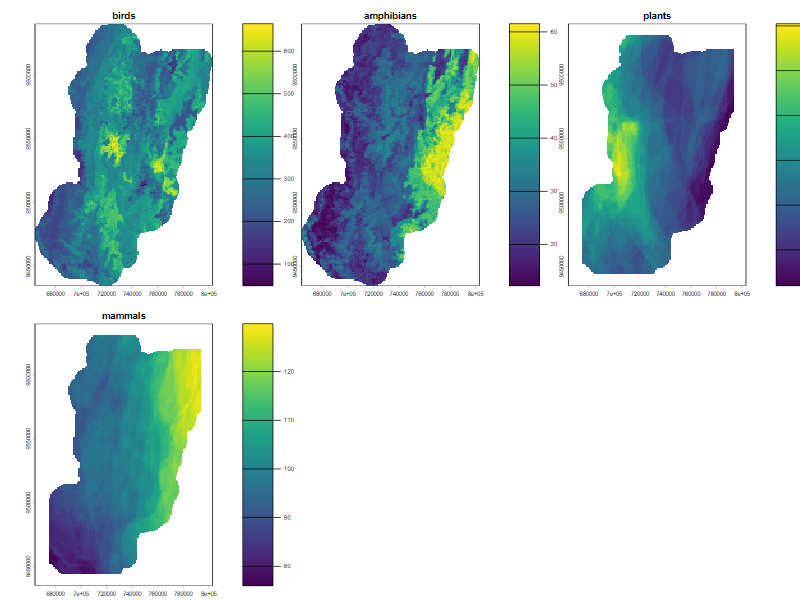

In [23]:
plot(richness)

## 2.2 Beta div

In [24]:
betadiv = rast("../../../DATOS/Raster/Betadiv/NMDS_cluster_beta_div.tif")

# **3. Conservation areas**

## 3.1. Iteraction over clusters

Procesando cluster: 0
Procesando cluster: 1
Procesando cluster: 2


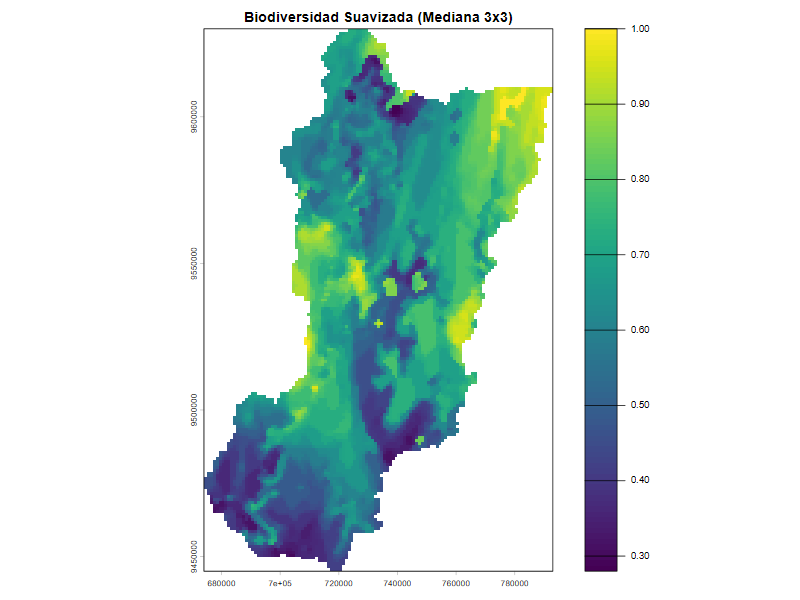

In [25]:


# -----------------------------
# 1. Raster de clusters
# -----------------------------
cluster <- betadiv$Cluster

# Asegurar misma geometría que la primera banda de riqueza
if (!compareGeom(cluster, richness[[1]], stopOnError = FALSE)) {
  if (!same.crs(cluster, richness[[1]])) {
    cluster <- project(cluster, richness[[1]], method = "near")
  } else {
    cluster <- resample(cluster, richness[[1]], method = "near")
  }
}

cluster <- crop(cluster, richness[[1]])
compareGeom(cluster, richness[[1]], stopOnError = TRUE)

# -----------------------------
# 2. Recortar a Zamora Chinchipe
# -----------------------------
# Si zamora_ch es vector, crop + mask
cluster  <- crop(cluster, zamora_ch)
cluster  <- mask(cluster, zamora_ch)

richness <- crop(richness, zamora_ch)
richness <- mask(richness, zamora_ch)

# Verificación final
compareGeom(cluster, richness[[1]], stopOnError = TRUE)

# -----------------------------
# 3. IDs de cluster
# -----------------------------
cluster_values <- unique(values(cluster))
cluster_values <- sort(na.omit(cluster_values))

# -----------------------------
# 4. Número de bandas de riqueza
# -----------------------------
n_bands <- nlyr(richness)

# -----------------------------
# 5. Lista de salida por cluster
# -----------------------------
cluster_result_list <- vector("list", length(cluster_values))

# -----------------------------
# 6. Iterar sobre cada cluster
# -----------------------------
for (j in seq_along(cluster_values)) {
  
  i <- cluster_values[j]
  message("Procesando cluster: ", i)
  
  # Máscara del cluster actual
  cluster_mask <- ifel(cluster == i, 1, NA)
  
  # Enmascarar las bandas de riqueza para ese cluster
  richness_cluster <- mask(richness, cluster_mask)
  
  # Lista para guardar bandas normalizadas
  richness_norm_list <- vector("list", n_bands)
  
  # -----------------------------
  # 6.1 Normalizar cada banda 0-1 dentro del cluster
  # -----------------------------
  for (k in 1:n_bands) {
    
    r_k <- richness_cluster[[k]]
    
    vals <- values(r_k)
    vals <- vals[!is.na(vals)]
    
    if (length(vals) == 0) {
      richness_norm_list[[k]] <- r_k
      next
    }
    
    min_val <- min(vals)
    max_val <- max(vals)
    
    if (max_val == min_val) {
      r_norm <- ifel(!is.na(r_k), 1, NA)
    } else {
      r_norm <- (r_k - min_val) / (max_val - min_val)
    }
    
    names(r_norm) <- paste0(names(richness)[k], "_norm")
    richness_norm_list[[k]] <- r_norm
  }
  
  # Stack de bandas normalizadas
  richness_norm_cluster <- rast(richness_norm_list)
  
  # -----------------------------
  # 6.2 CAMBIO: Obtener el MÁXIMO por píxel entre bandas
  # -----------------------------
  # En lugar de promediar, nos quedamos con el valor del grupo más destacado
  cluster_result <- max(richness_norm_cluster, na.rm = TRUE)
  names(cluster_result) <- paste0("cluster_", i, "_max_norm")
  
  vals_cluster <- values(cluster_result)
  vals_cluster <- vals_cluster[!is.na(vals_cluster)]
  
  if (length(vals_cluster) == 0) next
  
  cluster_result_list[[j]] <- cluster_result
}

# -----------------------------
# 7. Eliminar elementos NULL
# -----------------------------
cluster_result_list <- cluster_result_list[!sapply(cluster_result_list, is.null)]

# -----------------------------
# 8. Unir todos los clusters
# -----------------------------
richness_cluster_final <- cluster_result_list[[1]]

if (length(cluster_result_list) > 1) {
  for (k in 2:length(cluster_result_list)) {
    richness_cluster_final <- cover(richness_cluster_final, cluster_result_list[[k]])
  }
}

# -----------------------------
# 9. Suavizado espacial (Ventana móvil)
# -----------------------------
# Aplicamos una matriz de 3x3 (ventana de 3 píxeles) calculando la mediana
# w = 3 define una ventana de 3x3
richness_smoothed <- focal(
  richness_cluster_final, 
  w = 3, 
  fun = "median", 
  na.rm = TRUE
)

# Es importante volver a enmascarar con Zamora Chinchipe 
# para limpiar los bordes que el análisis focal pueda haber extendido
richness_smoothed <- mask(richness_smoothed, zamora_ch)

names(richness_smoothed) <- "richness_max_smoothed"



# -----------------------------
# 10. Visualización Final
# -----------------------------
plot(richness_smoothed, main = "Biodiversidad Suavizada (Mediana 3x3)")


## 3.2. Likert clasification

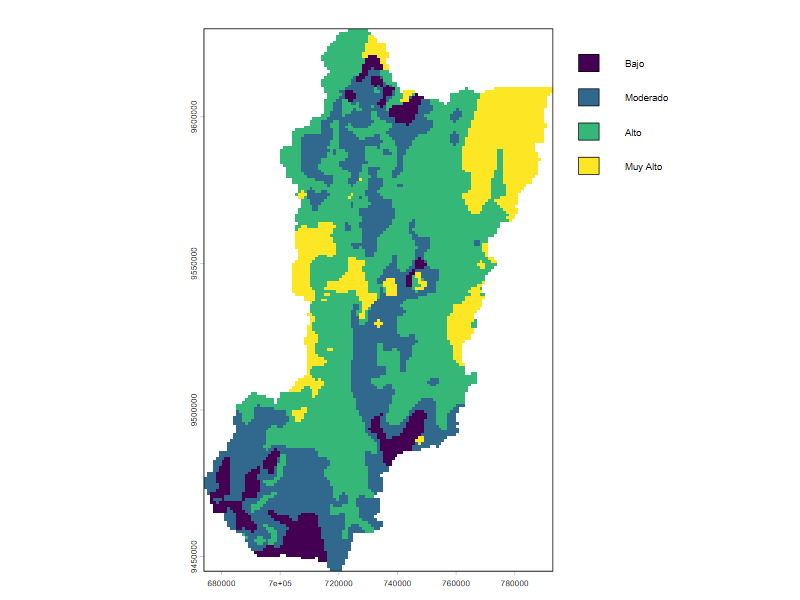

In [26]:
# -----------------------------
# 11. Clasificación tipo Likert
# -----------------------------
richness_cluster_likert <- classify(
  richness_smoothed,
  rcl = matrix(c(
    0.00, 0.20, 1,
    0.20, 0.40, 2,
    0.40, 0.60, 3,
    0.60, 0.80, 4,
    0.80, 1.00, 5
  ), ncol = 3, byrow = TRUE),
  include.lowest = TRUE,
  right = TRUE
)

names(richness_cluster_likert) <- "richness_cluster_likert"

# -----------------------------
# 12. Etiquetas de categorías
# -----------------------------
likert_levels <- data.frame(
  value = 1:5,
  category = c("Muy Bajo", "Bajo", "Moderado", "Alto", "Muy Alto")
)

levels(richness_cluster_likert) <- likert_levels

# -----------------------------
# 13. Visualizar
# -----------------------------

plot(richness_cluster_likert)

## 3.3. Export rasters

In [42]:
writeRaster(richness,"../../../DATOS/Raster/Conservation_areas/richness_z_ch_all.tif" ,overwrite=TRUE)
writeRaster(richness_smoothed,"../../../DATOS/Raster/Conservation_areas/richness_z_ch_scaled.tif",overwrite=TRUE )
writeRaster(richness_cluster_likert,"../../../DATOS/Raster/Conservation_areas/richness_z_ch_likert.tif" ,overwrite=TRUE)

Warning message:
PROJ: proj_create_from_name: C:\Program Files\PostgreSQL\16\share\contrib\postgis-3.4\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 4 is expected. It comes from another PROJ installation. (GDAL error 1) 
Warning message:
PROJ: proj_create_from_name: C:\Program Files\PostgreSQL\16\share\contrib\postgis-3.4\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 4 is expected. It comes from another PROJ installation. (GDAL error 1) 
Warning message:
PROJ: proj_create_from_name: C:\Program Files\PostgreSQL\16\share\contrib\postgis-3.4\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 4 is expected. It comes from another PROJ installation. (GDAL error 1) 


## 3.3. Conservation summary

### Zamora Ch

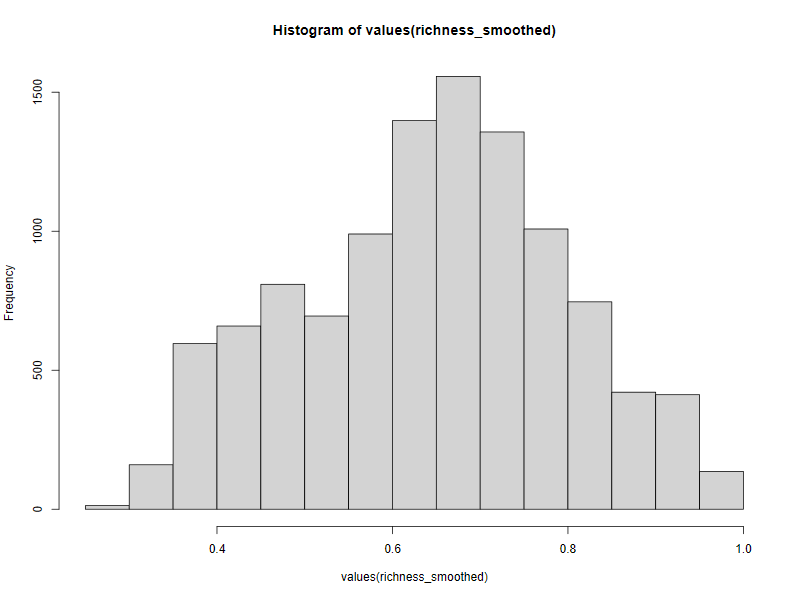

In [27]:
hist(values(richness_smoothed))

In [28]:
mean(na.omit(values(richness_smoothed)))

[1] 0.6449968

In [29]:
# -----------------------------
# 1. Frecuencia de clases
# -----------------------------
freq_table_z_ch <- as.data.frame(freq(richness_cluster_likert))

# -----------------------------
# 2. Área por clase (km²)
# -----------------------------
# área de cada celda en km²
cell_area_km2 <- prod(res(richness_cluster_likert)) / 1e6

freq_table_z_ch <- freq_table_z_ch %>%
  rename(categoria = value, n_pixeles = count) %>%
  mutate(
    area_km2 = n_pixeles * cell_area_km2
  )

# -----------------------------
# 3. Porcentaje
# -----------------------------
area_total <- sum(freq_table_z_ch$area_km2)

freq_table_z_ch <- freq_table_z_ch %>%
  mutate(
    porcentaje = (area_km2 / area_total) * 100
  )

# -----------------------------
# 4. Resultado final
# -----------------------------
freq_table_z_ch

  layer categoria n_pixeles area_km2 porcentaje
1     1      Bajo       769      769   7.018344
2     1  Moderado      3153     3153  28.776125
3     1      Alto      5320     5320  48.553436
4     1  Muy Alto      1715     1715  15.652095

### By ACUS

In [30]:


# -----------------------------
# 1. Preparar objetos
# -----------------------------
r <- richness_cluster_likert
acus_vect <- vect(acus_area)

# Asegurar mismo CRS
if (!same.crs(r, acus_vect)) {
  acus_vect <- project(acus_vect, crs(r))
}

# -----------------------------
# 2. Área de celda
# -----------------------------
cell_area_m2  <- prod(res(r))
cell_area_ha  <- cell_area_m2 / 10000
cell_area_km2 <- cell_area_m2 / 1e6

# -----------------------------
# 3. Totales por categoría en todo el raster
# -----------------------------
freq_total <- as.data.frame(freq(r)) %>%
  rename(categoria = value, n_pixeles_total = count) %>%
  mutate(
    area_total_categoria_ha  = n_pixeles_total * cell_area_ha,
    area_total_categoria_km2 = n_pixeles_total * cell_area_km2
  )

# -----------------------------
# 4. Estadísticas por polígono
# -----------------------------
res_list <- vector("list", nrow(acus_vect))

for (i in 1:nrow(acus_vect)) {
  
  pol_i <- acus_vect[i]
  nombre_i <- pol_i$Nombre
  
  # Raster dentro del polígono
  r_i <- crop(r, pol_i)
  r_i <- mask(r_i, pol_i)
  
  # Frecuencia de categorías en el polígono
  freq_i <- as.data.frame(freq(r_i))
  
  if (nrow(freq_i) == 0) next
  
  freq_i <- freq_i %>%
    rename(categoria = value, n_pixeles_poligono = count) %>%
    mutate(
      Nombre = nombre_i,
      area_categoria_poligono_ha  = n_pixeles_poligono * cell_area_ha,
      area_categoria_poligono_km2 = n_pixeles_poligono * cell_area_km2
    )
  
  # Área total rasterizada dentro del polígono
  area_total_poligono_ha <- sum(freq_i$area_categoria_poligono_ha, na.rm = TRUE)
  
  freq_i <- freq_i %>%
    mutate(
      porcentaje_dentro_poligono = (area_categoria_poligono_ha / area_total_poligono_ha) * 100
    )
  
  res_list[[i]] <- freq_i
}

tabla_poligonos <- bind_rows(res_list)

# -----------------------------
# 5. Unir con totales del raster
# -----------------------------
tabla_final <- tabla_poligonos %>%
  left_join(freq_total, by = "categoria") %>%
  mutate(
    porcentaje_de_categoria_en_raster = (area_categoria_poligono_ha / area_total_categoria_ha) * 100
  ) %>%
  select(
    Nombre,
    categoria,
    n_pixeles_poligono,
    area_categoria_poligono_ha,
    area_categoria_poligono_km2,
    porcentaje_dentro_poligono,
    n_pixeles_total,
    area_total_categoria_ha,
    area_total_categoria_km2,
    porcentaje_de_categoria_en_raster
  ) %>%
  arrange(Nombre, categoria)


orden_likert <- c("Muy Bajo", "Bajo", "Moderado", "Alto", "Muy Alto")

tabla_final <- tabla_final %>%
  mutate(
    categoria = factor(categoria, levels = orden_likert, ordered = TRUE)
  ) %>%
  arrange(Nombre, categoria)

tabla_final

                  Nombre categoria n_pixeles_poligono area_categoria_poligono_ha area_categoria_poligono_km2
1             Bracamoros      Bajo                218                      21800                         218
2             Bracamoros  Moderado                743                      74300                         743
3             Bracamoros      Alto                777                      77700                         777
4             Bracamoros  Muy Alto                 48                       4800                          48
5  Cordillera del Condor      Bajo                 27                       2700                          27
6  Cordillera del Condor  Moderado                239                      23900                         239
7  Cordillera del Condor      Alto                884                      88400                         884
8  Cordillera del Condor  Muy Alto                699                      69900                         699
9        Fuentes de

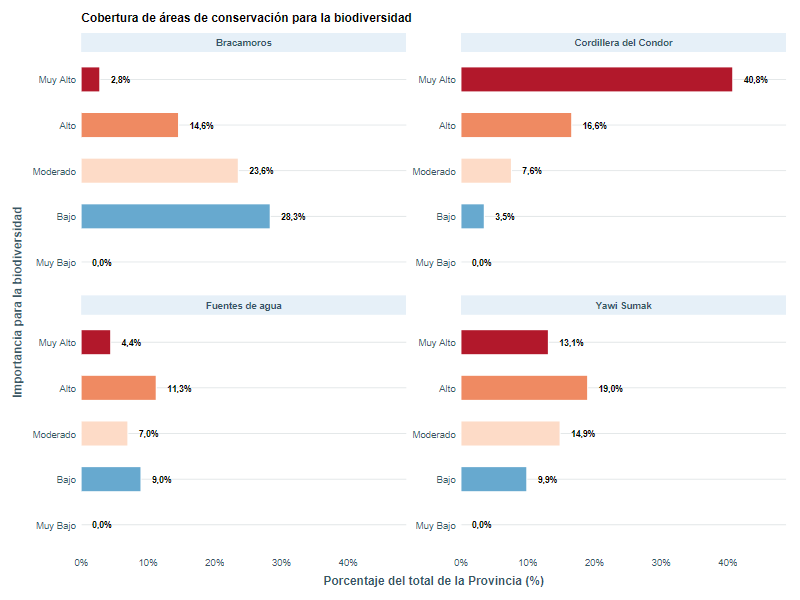

In [38]:
orden_likert <- c("Muy Bajo", "Bajo", "Moderado", "Alto", "Muy Alto")

# -----------------------------
# Completar categorías faltantes
# -----------------------------
tabla_plot <- tabla_final %>%
  mutate(
    categoria = factor(categoria, levels = orden_likert, ordered = TRUE)
  ) %>%
  complete(
    Nombre,
    categoria,
    fill = list(porcentaje_de_categoria_en_raster = 0)
  )

# recalcular offset con datos completos
max_val <- max(tabla_plot$porcentaje_de_categoria_en_raster, na.rm = TRUE)
offset_etiqueta <- max_val * 0.04

# -----------------------------
# Gráfica
# -----------------------------
plot_likert_acus <- ggplot(
  tabla_plot,
  aes(x = categoria, y = porcentaje_de_categoria_en_raster, fill = categoria)
) +
  geom_bar(
    stat = "identity",
    width = 0.55,
    color = "white"
  ) +
  geom_text(
    aes(
      y = porcentaje_de_categoria_en_raster + offset_etiqueta,
      label = paste0(
        number(
          porcentaje_de_categoria_en_raster,
          accuracy = 0.1,
          big.mark = ".",
          decimal.mark = ","
        ),
        "%"
      )
    ),
    hjust = 0,
    color = "black",
    fontface = "bold",
    size = 3
  ) +
  coord_flip() +
  facet_wrap(~Nombre, scales = "free_y") +
  scale_fill_manual(
    values = c(
      "Muy Bajo" = "#2166AC",   # azul
      "Bajo" = "#67A9CF",
      "Moderado" = "#FDDBC7",
      "Alto" = "#EF8A62",
      "Muy Alto" = "#B2182B"    # rojo
    )
  ) +
  scale_y_continuous(
    labels = function(x) paste0(
      number(x, accuracy = 1, big.mark = ".", decimal.mark = ","),
      "%"
    ),
    expand = expansion(mult = c(0, 0.15))
  ) +
  labs(
    title = "Cobertura de áreas de conservación para la biodiversidad",
    x = "Importancia para la biodiversidad",
    y = "Porcentaje del total de la Provincia (%)"
  ) +
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none",
    strip.text = element_text(face = "bold"),
    plot.title = element_text(size = 12) 
  )

plot_likert_acus

In [39]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Conservation_biodiversity/Distribution_sp_province_acus.png", 
  plot = plot_likert_acus, 
  device = "png",
  width = 200,               # Ancho en mm
  height = 150,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### All ACUS

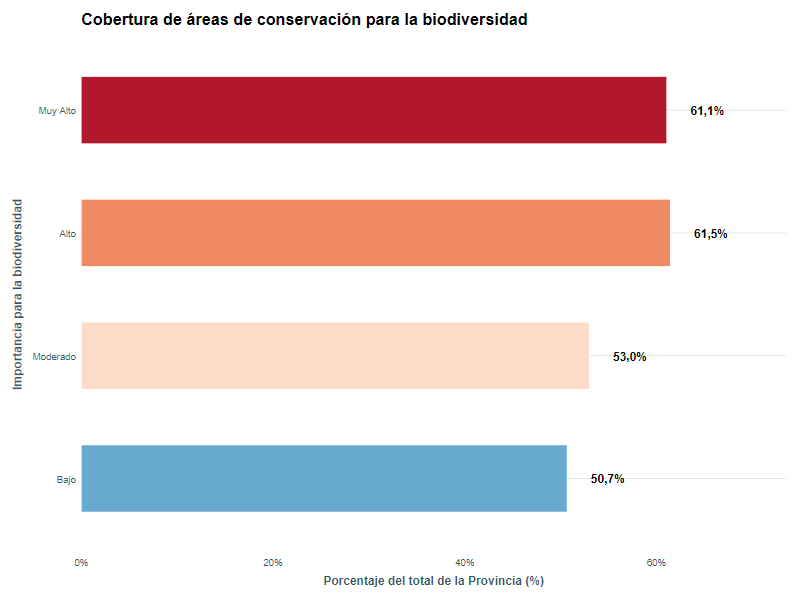

In [34]:


orden_likert <- c("Muy Bajo", "Bajo", "Moderado", "Alto", "Muy Alto")

# -----------------------------
# 1. Suma total del shp por categoría (basado en tabla_final)
# -----------------------------
tabla_total_shp <- tabla_final %>%
  mutate(
    categoria = factor(categoria, levels = orden_likert, ordered = TRUE)
  ) %>%
  group_by(categoria) %>%
  summarise(
    area_total_en_shp_ha = sum(area_categoria_poligono_ha, na.rm = TRUE),
    porcentaje_total_en_shp = sum(porcentaje_de_categoria_en_raster, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(categoria)

# -----------------------------
# 2. Gráfica (porcentaje total dentro del shp)
# -----------------------------
max_val <- max(tabla_total_shp$porcentaje_total_en_shp, na.rm = TRUE)
offset_etiqueta <- max_val * 0.04

plot_likert_total_shp <- ggplot(
  tabla_total_shp,
  aes(x = categoria, y = porcentaje_total_en_shp, fill = categoria)
) +
  geom_bar(
    stat = "identity",
    width = 0.55,
    color = "white"
  ) +
  geom_text(
    aes(
      y = porcentaje_total_en_shp + offset_etiqueta,
      label = paste0(
        number(
          porcentaje_total_en_shp,
          accuracy = 0.1,
          big.mark = ".",
          decimal.mark = ","
        ),
        "%"
      )
    ),
    hjust = 0,
    color = "black",
    fontface = "bold",
    size = 4.2
  ) +
  coord_flip() +
  scale_fill_manual(
    values = c(
      "Muy Bajo" = "#2166AC",
      "Bajo" = "#67A9CF",
      "Moderado" = "#FDDBC7",
      "Alto" = "#EF8A62",
      "Muy Alto" = "#B2182B"
    )
  ) +
  scale_y_continuous(
    labels = function(x) paste0(
      number(x, accuracy = 1, big.mark = ".", decimal.mark = ","),
      "%"
    ),
    expand = expansion(mult = c(0, 0.15))
  ) +
  labs(
    title = "Cobertura de áreas de conservación para la biodiversidad",
    x = "Importancia para la biodiversidad",
    y = "Porcentaje del total de la Provincia (%)"
  ) +
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

plot_likert_total_shp

In [35]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Conservation_biodiversity/Distribution_sp_province_acus_total.png", 
  plot = plot_likert_total_shp, 
  device = "png",
  width = 200,               # Ancho en mm
  height = 150,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)